<a href="https://colab.research.google.com/github/aniray2908/ML-foundations-rebuild/blob/main/unsupervised_learning/demos/05_cluster_validation_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cluster Validation Demonstration

Goal:
- Compare Silhouette, Davies–Bouldin, and Calinski–Harabasz indices
- Observe behavior across different K
- Examine metric bias toward compact clusters
- Compare behavior on spherical, elongated, and non-spherical data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [2]:
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42)

In [3]:
K_range = range(2, 9)

sil_scores = []
dbi_scores = []
ch_scores = []

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    sil_scores.append(silhouette_score(X, labels))
    dbi_scores.append(davies_bouldin_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

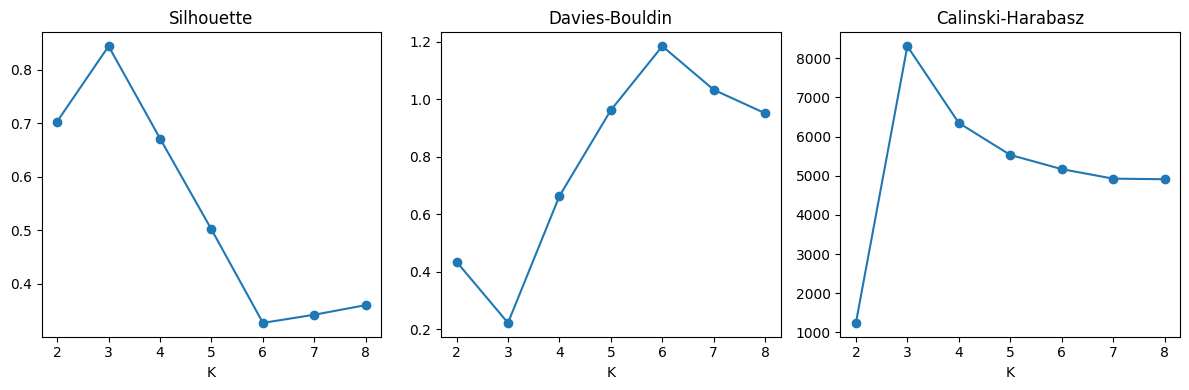

In [4]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette")
plt.xlabel("K")

plt.subplot(1,3,2)
plt.plot(K_range, dbi_scores, marker='o')
plt.title("Davies-Bouldin")
plt.xlabel("K")

plt.subplot(1,3,3)
plt.plot(K_range, ch_scores, marker='o')
plt.title("Calinski-Harabasz")
plt.xlabel("K")

plt.tight_layout()
plt.show()

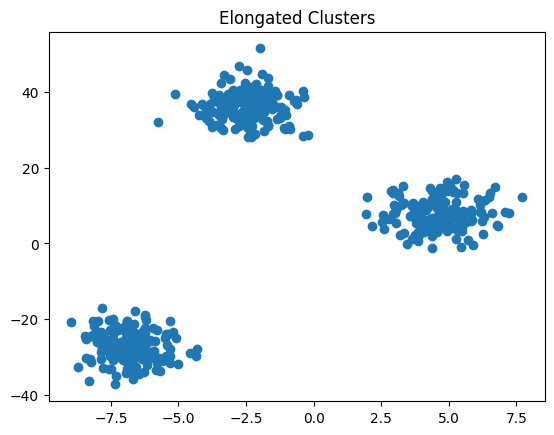

In [5]:
X_elong, _ = make_blobs(n_samples=500, centers=3, cluster_std=1.0, random_state=42)

# Stretch along one axis
X_elong[:,1] *= 4

plt.scatter(X_elong[:,0], X_elong[:,1])
plt.title("Elongated Clusters")
plt.show()

In [6]:
model = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_elong = model.fit_predict(X_elong)

print("Silhouette:", silhouette_score(X_elong, labels_elong))
print("DBI:", davies_bouldin_score(X_elong, labels_elong))
print("CH:", calinski_harabasz_score(X_elong, labels_elong))

Silhouette: 0.8432919199400704
DBI: 0.21587324894298357
CH: 10344.09271523527


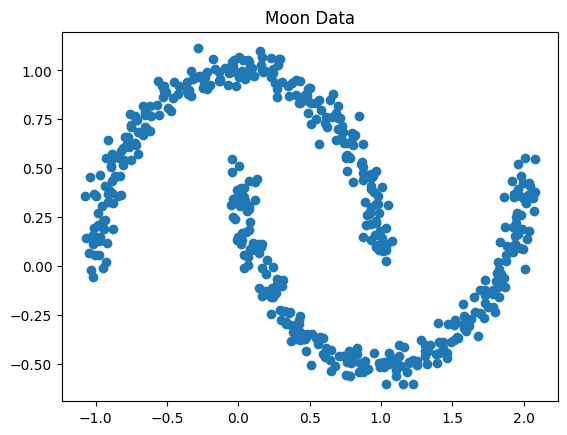

In [7]:
X_moon, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

plt.scatter(X_moon[:,0], X_moon[:,1])
plt.title("Moon Data")
plt.show()

In [8]:
model = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_moon = model.fit_predict(X_moon)

print("Silhouette:", silhouette_score(X_moon, labels_moon))
print("DBI:", davies_bouldin_score(X_moon, labels_moon))
print("CH:", calinski_harabasz_score(X_moon, labels_moon))

Silhouette: 0.4887915744184056
DBI: 0.7825794833025568
CH: 736.3984001670055


Observations:

1. All metrics reward compact, well-separated clusters.
2. Elongated clusters are penalized.
3. Non-spherical clusters may receive lower scores.
4. Internal validation metrics encode geometric assumptions.
5. No metric is universally correct.

Cluster validation measures structure under assumptions,
not objective truth.